# 5. Visualise PyNNLF Output: AEDP Aggregation Levels

Visualises the 1-day-ahead AEDP aggregation-level experiment after notebooks 3 and 4 have been run. This version assumes 3 samples per aggregation level.


## 1. Setup And Paths

In [1]:
from pathlib import Path
import sys

def find_publication_project(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "specs").exists() and (candidate / "data").exists() and (candidate / "results").exists():
            return candidate
    raise FileNotFoundError("Could not find publication/journal_article_1 from the current working directory.")

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "pynnlf").exists():
            return candidate
    raise FileNotFoundError("Could not find the PyNNLF repo root.")
PROJECT_DIR = find_publication_project()
REPO_ROOT = find_repo_root(PROJECT_DIR)
print(f"Publication project: {PROJECT_DIR}")
print(f"Repository root: {REPO_ROOT}")
import pandas as pd
import matplotlib.pyplot as plt
RESULTS_DIR = PROJECT_DIR / "results" / "03_aedp_aggregation_level"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ORDER = ["m1_naive_hp1", "m6_lr_hp1", "m17_xgb_hp1"]
MODEL_LABELS = {"m1_naive_hp1": "Naive", "m6_lr_hp1": "Linear regression", "m17_xgb_hp1": "XGBoost"}
COLORS = {"m1_naive_hp1": "#2f5597", "m6_lr_hp1": "#70ad47", "m17_xgb_hp1": "#c55a11"}
SAMPLES_PER_LEVEL = 3
AGGREGATION_LEVELS = [1, 10, 100, 1000]
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "axes.grid": True, "grid.alpha": 0.25})
def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

Publication project: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1
Repository root: C:\Users\z5404477\Documents\PyNNLF


## 2. Load Processed Tables

In [2]:
required = {"recap": RESULTS_DIR / "aedp_aggregation_fh8_recap.csv", "summary": RESULTS_DIR / "aedp_aggregation_fh8_summary_by_level_model.csv"}
missing = [str(path) for path in required.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing processed result files. Run notebook 4 first. " + str(missing))
recap = pd.read_csv(required["recap"])
summary = pd.read_csv(required["summary"])
display(summary.round(3))

,aggregation_level_hh,model_name,mean_test_nRMSE,sample_std_test_nRMSE,mean_test_nRMSE_stddev,mean_runtime_s,n_samples
0,1,m1_naive_hp1,20.647,6.209,2.905,0.002,3
1,1,m6_lr_hp1,16.956,5.254,2.970,0.817,3
2,1,m17_xgb_hp1,16.392,5.201,3.154,30.234,3
3,10,m1_naive_hp1,18.941,4.009,2.530,0.001,3
4,10,m6_lr_hp1,16.058,3.469,1.999,0.703,3
5,10,m17_xgb_hp1,14.529,2.367,1.747,26.570,3
6,100,m1_naive_hp1,23.482,0.750,2.936,0.002,3
7,100,m6_lr_hp1,20.210,0.630,2.409,0.616,3
8,100,m17_xgb_hp1,17.285,0.545,1.950,24.117,3
9,1000,m1_naive_hp1,24.630,0.616,3.034,0.002,3


## 3. Mean nRMSE By Aggregation Level

Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\03_aedp_aggregation_level\figures\fig01_aedp_aggregation_mean_nrmse_by_level.png


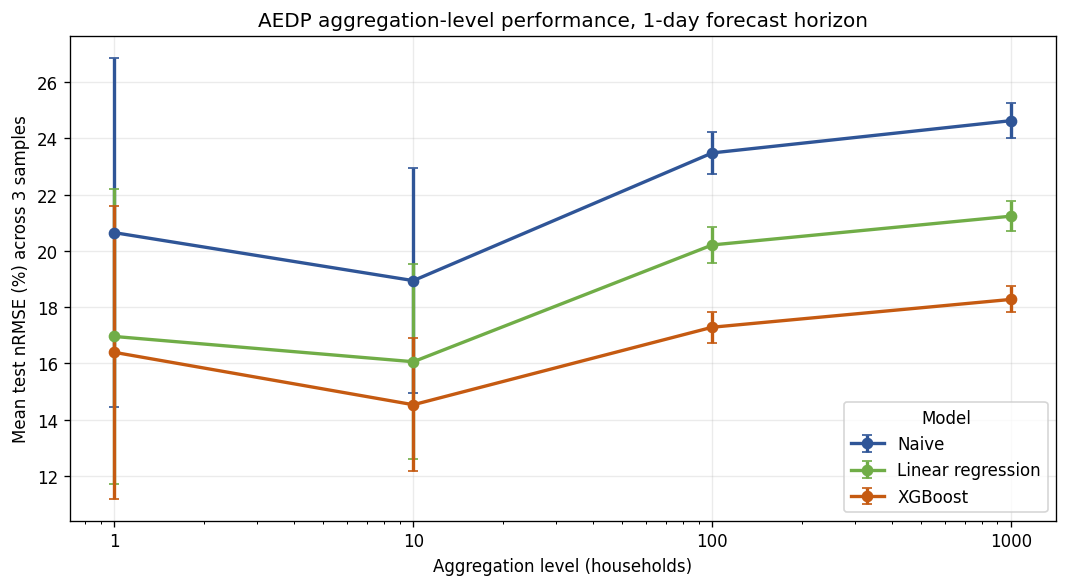

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
for model in MODEL_ORDER:
    model_rows = summary.loc[summary["model_name"].eq(model)].sort_values("aggregation_level_hh")
    ax.errorbar(model_rows["aggregation_level_hh"], model_rows["mean_test_nRMSE"], yerr=model_rows["sample_std_test_nRMSE"], marker="o", capsize=3, linewidth=2, color=COLORS[model], label=MODEL_LABELS[model])
ax.set_xscale("log")
ax.set_xticks(AGGREGATION_LEVELS)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("Aggregation level (households)")
ax.set_ylabel(f"Mean test nRMSE (%) across {SAMPLES_PER_LEVEL} samples")
ax.set_title("AEDP aggregation-level performance, 1-day forecast horizon")
ax.legend(title="Model")
fig.tight_layout()
save_figure(fig, "fig01_aedp_aggregation_mean_nrmse_by_level.png")
plt.show()

## 4. Sample Distribution By Model And Level

C:\Users\z5404477\AppData\Local\Temp\ipykernel_32928\3814036804.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(level) for level in AGGREGATION_LEVELS], showmeans=True)
C:\Users\z5404477\AppData\Local\Temp\ipykernel_32928\3814036804.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(level) for level in AGGREGATION_LEVELS], showmeans=True)
C:\Users\z5404477\AppData\Local\Temp\ipykernel_32928\3814036804.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(level) for level in AGGREGATION_LEVELS], showmeans=True)


Saved: C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\03_aedp_aggregation_level\figures\fig02_aedp_aggregation_nrmse_boxplots.png


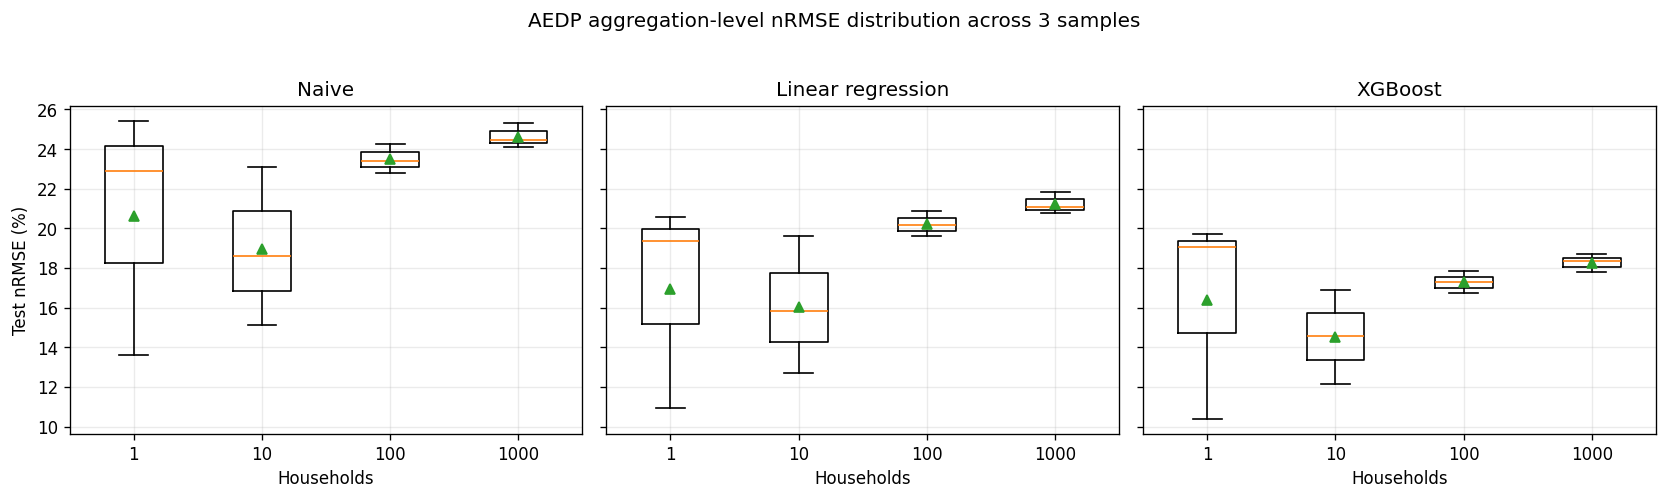

In [4]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(14, 4), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    data = [recap.loc[(recap["model_name"].eq(model)) & (recap["aggregation_level_hh"].eq(level)), "test_nRMSE"].dropna().to_numpy() for level in AGGREGATION_LEVELS]
    ax.boxplot(data, labels=[str(level) for level in AGGREGATION_LEVELS], showmeans=True)
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("Households")
axes[0].set_ylabel("Test nRMSE (%)")
fig.suptitle(f"AEDP aggregation-level nRMSE distribution across {SAMPLES_PER_LEVEL} samples", y=1.03)
fig.tight_layout()
save_figure(fig, "fig02_aedp_aggregation_nrmse_boxplots.png")
plt.show()

## 5. Figure Inventory

In [5]:
for path in sorted(FIGURES_DIR.glob("fig*.png")):
    print(path)

C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\03_aedp_aggregation_level\figures\fig01_aedp_aggregation_mean_nrmse_by_level.png
C:\Users\z5404477\Documents\PyNNLF\publication\journal_article_1\results\03_aedp_aggregation_level\figures\fig02_aedp_aggregation_nrmse_boxplots.png
